# Pandas
* https://pandas.pydata.org/docs/

In [1]:
import pandas as pd
pd.__version__

'3.0.5'

In [2]:
import sys
from pathlib import Path
sys.path.append(Path.cwd().parent.parent.joinpath('src/util').as_posix())
# print(sys.path)

from util.datasets import *

# Time Series

## Python标准库: datetime, time, calendar

In [3]:
from datetime import datetime

In [4]:
now = datetime.now()

In [5]:
now

datetime.datetime(2026, 9, 20, 18, 39, 5, 324614)

In [6]:
now.year, now.month, now.day

(2026, 9, 20)

In [7]:
delta = datetime(2011, 1, 7) - datetime(2008, 6, 24, 8, 15) # 计算时间差

In [8]:
delta # 时间差: (天数, 秒数)

datetime.timedelta(days=926, seconds=56700)

In [9]:
delta.days, delta.seconds

(926, 56700)

In [10]:
from datetime import timedelta # 时间差构造
start = datetime(2011, 1, 7)
start + timedelta(12)

datetime.datetime(2011, 1, 19, 0, 0)

In [11]:
start - 2 * timedelta(12)

datetime.datetime(2010, 12, 14, 0, 0)

In [12]:
stamp = datetime(2011, 1, 3)

In [13]:
str(stamp)

'2011-01-03 00:00:00'

In [14]:
value = '2011-01-03'
datetime.strptime(value, '%Y-%m-%d') # 字符串与datetime的转换

datetime.datetime(2011, 1, 3, 0, 0)

In [15]:
from dateutil.parser import parse
parse('2011-01-03') # 自动解析日期格式

datetime.datetime(2011, 1, 3, 0, 0)

## 时间序列数据结构: Series

In [16]:
dates = [datetime(2011,1,2), datetime(2011,1,5), datetime(2011,1,7), 
         datetime(2011,1,8), datetime(2011,1,10), datetime(2011,1,12)]

In [17]:
import numpy as np
import pandas as pd
from pandas import Series, DataFrame
ts = Series(np.random.randn(6), index=dates) # Series: 一组数据和时间索引

In [18]:
ts

2011-01-02    1.485103
2011-01-05   -0.134546
2011-01-07    0.021834
2011-01-08   -0.035567
2011-01-10   -0.126725
2011-01-12    0.040715
dtype: float64

In [19]:
type(ts)

pandas.Series

In [20]:
ts.index # 访问索引, 数据类型为datetime64[ns]

DatetimeIndex(['2011-01-02', '2011-01-05', '2011-01-07', '2011-01-08',
               '2011-01-10', '2011-01-12'],
              dtype='datetime64[us]', freq=None)

In [21]:
ts[::2] # 步长为2

2011-01-02    1.485103
2011-01-07    0.021834
2011-01-10   -0.126725
dtype: float64

In [22]:
ts + ts[::2] # 按日期对齐

2011-01-02    2.970206
2011-01-05         NaN
2011-01-07    0.043668
2011-01-08         NaN
2011-01-10   -0.253451
2011-01-12         NaN
dtype: float64

In [23]:
ts.index.dtype

dtype('<M8[us]')

In [24]:
stamp = ts.index[0]

In [25]:
stamp # 索引元素为pandas的Timestamp对象

Timestamp('2011-01-02 00:00:00')

### TimeSeries的索引, 选取和子集构造

In [26]:
ts

2011-01-02    1.485103
2011-01-05   -0.134546
2011-01-07    0.021834
2011-01-08   -0.035567
2011-01-10   -0.126725
2011-01-12    0.040715
dtype: float64

In [27]:
stamp = ts.index[2]

In [28]:
ts[stamp] # 访问值: 使用索引中元素

np.float64(0.02183403771520012)

In [29]:
ts['2011-01-07'], ts['20110107'] # 访问值: 使用索引中元素的字符串表示

(np.float64(0.02183403771520012), np.float64(0.02183403771520012))

In [30]:
longer_ts = Series(np.random.randn(1000), 
                   index=pd.date_range('2000-01-01', periods=1000)) # 使用日期的range()方法

In [31]:
longer_ts['2000-01'] # 只传入年或者年月做slice

2000-01-01    0.826296
2000-01-02   -1.505822
2000-01-03   -0.121618
2000-01-04   -0.141055
2000-01-05   -1.387355
2000-01-06    1.041476
2000-01-07    0.428232
2000-01-08   -0.455156
2000-01-09   -2.981759
2000-01-10    0.529633
2000-01-11    0.025754
2000-01-12    0.382164
2000-01-13    2.723700
2000-01-14   -0.229979
2000-01-15   -1.281606
2000-01-16    0.660557
2000-01-17   -0.721576
2000-01-18   -0.277557
2000-01-19    1.689390
2000-01-20    0.088063
2000-01-21    2.350895
2000-01-22   -0.621631
2000-01-23   -0.846257
2000-01-24    1.496045
2000-01-25   -1.246986
2000-01-26   -0.040822
2000-01-27   -0.435075
2000-01-28   -0.872049
2000-01-29   -0.332992
2000-01-30   -0.148877
2000-01-31   -0.024241
Freq: D, dtype: float64

In [32]:
ts

2011-01-02    1.485103
2011-01-05   -0.134546
2011-01-07    0.021834
2011-01-08   -0.035567
2011-01-10   -0.126725
2011-01-12    0.040715
dtype: float64

In [33]:
ts[datetime(2011, 1, 7):] # 使用datetime值做slice

2011-01-07    0.021834
2011-01-08   -0.035567
2011-01-10   -0.126725
2011-01-12    0.040715
dtype: float64

In [34]:
ts['1/6/2011':'1/11/2011'] # 使用索引中元素字符串形式做slice

2011-01-07    0.021834
2011-01-08   -0.035567
2011-01-10   -0.126725
dtype: float64

In [35]:
ts.truncate(after='2011-01-08') # 截取: 不晚于指定日期

2011-01-02    1.485103
2011-01-05   -0.134546
2011-01-07    0.021834
2011-01-08   -0.035567
dtype: float64

In [36]:
# DataFrame
dates = pd.date_range('2000-01-01', periods=100, freq='D')
dates

DatetimeIndex(['2000-01-01', '2000-01-02', '2000-01-03', '2000-01-04',
               '2000-01-05', '2000-01-06', '2000-01-07', '2000-01-08',
               '2000-01-09', '2000-01-10', '2000-01-11', '2000-01-12',
               '2000-01-13', '2000-01-14', '2000-01-15', '2000-01-16',
               '2000-01-17', '2000-01-18', '2000-01-19', '2000-01-20',
               '2000-01-21', '2000-01-22', '2000-01-23', '2000-01-24',
               '2000-01-25', '2000-01-26', '2000-01-27', '2000-01-28',
               '2000-01-29', '2000-01-30', '2000-01-31', '2000-02-01',
               '2000-02-02', '2000-02-03', '2000-02-04', '2000-02-05',
               '2000-02-06', '2000-02-07', '2000-02-08', '2000-02-09',
               '2000-02-10', '2000-02-11', '2000-02-12', '2000-02-13',
               '2000-02-14', '2000-02-15', '2000-02-16', '2000-02-17',
               '2000-02-18', '2000-02-19', '2000-02-20', '2000-02-21',
               '2000-02-22', '2000-02-23', '2000-02-24', '2000-02-25',
      

In [37]:
long_df = DataFrame(np.random.randn(100,4), 
                   index = dates,
                   columns=['Colorado', 'Texas', 'New York', 'Ohio'])
long_df

,Colorado,Texas,New York,Ohio
2000-01-01,0.407908,0.730977,0.450547,-0.622526
2000-01-02,-0.363310,-0.161272,-0.263946,-0.002598
2000-01-03,-1.396207,1.346306,-0.850746,0.839884
2000-01-04,-0.537683,1.997290,0.328463,-0.720986
2000-01-05,2.091438,0.033572,-0.690355,1.298264
...,...,...,...,...
2000-04-05,0.791407,0.585810,1.240050,-0.378497
2000-04-06,-0.008803,-1.932856,-2.407370,-0.661548
2000-04-07,-1.286734,-0.270713,0.378583,0.815357
2000-04-08,-0.299562,1.105488,0.953340,0.188096


In [38]:
# 带重复索引的时间序列
dates = pd.DatetimeIndex(['2000-01-01','2000-01-02','2000-01-02','2000-01-02','2000-01-03'])
dup_ts = Series(np.arange(5), index=dates)
dup_ts

2000-01-01    0
2000-01-02    1
2000-01-02    2
2000-01-02    3
2000-01-03    4
dtype: int64

In [39]:
dup_ts.index.is_unique # 判断索引取值是否唯一

False

In [40]:
dup_ts['20000103'] # 标量值

np.int64(4)

In [41]:
dup_ts['1/2/2000'] # 切片

2000-01-02    1
2000-01-02    2
2000-01-02    3
dtype: int64

In [42]:
grouped = dup_ts.groupby(level=0) # 聚合
grouped

In [43]:
grouped.mean(), grouped.count()

(2000-01-01    0.0
 2000-01-02    2.0
 2000-01-03    4.0
 dtype: float64,
 2000-01-01    1
 2000-01-02    3
 2000-01-03    1
 dtype: int64)

## 日期的范围, 频率和移动

In [44]:
ts

2011-01-02    1.485103
2011-01-05   -0.134546
2011-01-07    0.021834
2011-01-08   -0.035567
2011-01-10   -0.126725
2011-01-12    0.040715
dtype: float64

In [45]:
# 重采样, 转化为具有固定频率的时间序列
# .resample() is now a deferred operation
ts_reample_as_day = ts.resample('D')
ts_reample_as_day

In [46]:
ts_reample_as_day.agg({value: lambda x: x}) #  自定义聚合函数: 显示值

,2011-01-03
2011-01-02,1.485103
2011-01-03,[]
2011-01-04,[]
2011-01-05,-0.134546
2011-01-06,[]
2011-01-07,0.021834
2011-01-08,-0.035567
2011-01-09,[]
2011-01-10,-0.126725
2011-01-11,[]


### 日期范围

In [47]:
index = pd.date_range('2012-04-01', '2012-06-01') # 默认频率为天
index

DatetimeIndex(['2012-04-01', '2012-04-02', '2012-04-03', '2012-04-04',
               '2012-04-05', '2012-04-06', '2012-04-07', '2012-04-08',
               '2012-04-09', '2012-04-10', '2012-04-11', '2012-04-12',
               '2012-04-13', '2012-04-14', '2012-04-15', '2012-04-16',
               '2012-04-17', '2012-04-18', '2012-04-19', '2012-04-20',
               '2012-04-21', '2012-04-22', '2012-04-23', '2012-04-24',
               '2012-04-25', '2012-04-26', '2012-04-27', '2012-04-28',
               '2012-04-29', '2012-04-30', '2012-05-01', '2012-05-02',
               '2012-05-03', '2012-05-04', '2012-05-05', '2012-05-06',
               '2012-05-07', '2012-05-08', '2012-05-09', '2012-05-10',
               '2012-05-11', '2012-05-12', '2012-05-13', '2012-05-14',
               '2012-05-15', '2012-05-16', '2012-05-17', '2012-05-18',
               '2012-05-19', '2012-05-20', '2012-05-21', '2012-05-22',
               '2012-05-23', '2012-05-24', '2012-05-25', '2012-05-26',
      

In [48]:
pd.date_range(start='2012-04-01', periods=20) # 使用period指定日期数量

DatetimeIndex(['2012-04-01', '2012-04-02', '2012-04-03', '2012-04-04',
               '2012-04-05', '2012-04-06', '2012-04-07', '2012-04-08',
               '2012-04-09', '2012-04-10', '2012-04-11', '2012-04-12',
               '2012-04-13', '2012-04-14', '2012-04-15', '2012-04-16',
               '2012-04-17', '2012-04-18', '2012-04-19', '2012-04-20'],
              dtype='datetime64[us]', freq='D')

In [49]:
pd.date_range(end='2012-04-01', periods=20)

DatetimeIndex(['2012-03-13', '2012-03-14', '2012-03-15', '2012-03-16',
               '2012-03-17', '2012-03-18', '2012-03-19', '2012-03-20',
               '2012-03-21', '2012-03-22', '2012-03-23', '2012-03-24',
               '2012-03-25', '2012-03-26', '2012-03-27', '2012-03-28',
               '2012-03-29', '2012-03-30', '2012-03-31', '2012-04-01'],
              dtype='datetime64[us]', freq='D')

In [50]:
pd.date_range('2000-01-01', '2000-12-01', freq='BME') # 指定频率

DatetimeIndex(['2000-01-31', '2000-02-29', '2000-03-31', '2000-04-28',
               '2000-05-31', '2000-06-30', '2000-07-31', '2000-08-31',
               '2000-09-29', '2000-10-31', '2000-11-30'],
              dtype='datetime64[us]', freq='BME')

In [51]:
pd.date_range('2012-05-02 12:56:31', periods=5) # 保留时间戳信息

DatetimeIndex(['2012-05-02 12:56:31', '2012-05-03 12:56:31',
               '2012-05-04 12:56:31', '2012-05-05 12:56:31',
               '2012-05-06 12:56:31'],
              dtype='datetime64[us]', freq='D')

In [52]:
pd.date_range('2012-05-02 12:56:31', periods=5, normalize=True) # 不保留时间戳信息

DatetimeIndex(['2012-05-02', '2012-05-03', '2012-05-04', '2012-05-05',
               '2012-05-06'],
              dtype='datetime64[us]', freq='D')

### 频率和日期偏移

In [53]:
from pandas.tseries.offsets import Hour, Minute # 基础频率对应的日期偏移量对象

In [54]:
hour = Hour()
hour

<Hour>

In [55]:
four_hour = Hour(4)
four_hour

<4 * Hours>

In [56]:
pd.date_range('2000-01-01', '2000-01-03 23:59', freq='4h')# 频率由基础频率和乘数构成

DatetimeIndex(['2000-01-01 00:00:00', '2000-01-01 04:00:00',
               '2000-01-01 08:00:00', '2000-01-01 12:00:00',
               '2000-01-01 16:00:00', '2000-01-01 20:00:00',
               '2000-01-02 00:00:00', '2000-01-02 04:00:00',
               '2000-01-02 08:00:00', '2000-01-02 12:00:00',
               '2000-01-02 16:00:00', '2000-01-02 20:00:00',
               '2000-01-03 00:00:00', '2000-01-03 04:00:00',
               '2000-01-03 08:00:00', '2000-01-03 12:00:00',
               '2000-01-03 16:00:00', '2000-01-03 20:00:00'],
              dtype='datetime64[us]', freq='4h')

In [57]:
Hour(2) + Minute(30) # 偏移量对象加法

<150 * Minutes>

In [58]:
pd.date_range('2000-01-01', periods=10, freq='1h30min')

DatetimeIndex(['2000-01-01 00:00:00', '2000-01-01 01:30:00',
               '2000-01-01 03:00:00', '2000-01-01 04:30:00',
               '2000-01-01 06:00:00', '2000-01-01 07:30:00',
               '2000-01-01 09:00:00', '2000-01-01 10:30:00',
               '2000-01-01 12:00:00', '2000-01-01 13:30:00'],
              dtype='datetime64[us]', freq='90min')

In [59]:
# WOM: Week of Month
rng = pd.date_range('2012-01-01', '2012-09-01', freq='WOM-3FRI') # 每月的第3个星期五
rng

DatetimeIndex(['2012-01-20', '2012-02-17', '2012-03-16', '2012-04-20',
               '2012-05-18', '2012-06-15', '2012-07-20', '2012-08-17'],
              dtype='datetime64[us]', freq='WOM-3FRI')

### 数据移动和日期移动

In [60]:
ts = Series(np.random.randn(4), index=pd.date_range('2000-01-01', periods=4, freq='ME'))

In [61]:
ts

2000-01-31   -0.287694
2000-02-29    1.240149
2000-03-31    1.764747
2000-04-30   -0.815140
Freq: ME, dtype: float64

In [62]:
ts.shift(2) # 数据前移2个位置

2000-01-31         NaN
2000-02-29         NaN
2000-03-31   -0.287694
2000-04-30    1.240149
Freq: ME, dtype: float64

In [63]:
ts.shift(-2) # 数据后移2个位置

2000-01-31    1.764747
2000-02-29   -0.815140
2000-03-31         NaN
2000-04-30         NaN
Freq: ME, dtype: float64

In [64]:
# 仅移动时间戳, 数据保持不变
ts.shift(2, freq='ME')

2000-03-31   -0.287694
2000-04-30    1.240149
2000-05-31    1.764747
2000-06-30   -0.815140
Freq: ME, dtype: float64

In [65]:
# 使用偏移量移动时间戳
from pandas.tseries.offsets import Day, MonthEnd
now = datetime(2011,11,17)

In [66]:
now + Day(3)

Timestamp('2011-11-20 00:00:00')

In [67]:
now + MonthEnd()

Timestamp('2011-11-30 00:00:00')

In [68]:
offset = MonthEnd()
offset.rollforward(now) # now的月末

Timestamp('2011-11-30 00:00:00')

In [69]:
offset.rollback(now) # now的前一个月末

Timestamp('2011-10-31 00:00:00')

In [70]:
# 使用Series.groupby()
ts = Series(np.random.randn(20), index=pd.date_range('2000-01-15', periods=20, freq='4d'))
ts

C:\Users\87724\AppData\Local\Temp\ipykernel_15004\390288935.py:2: Pandas4Warning: 'd' is deprecated and will be removed in a future version, please use 'D' instead.
  ts = Series(np.random.randn(20), index=pd.date_range('2000-01-15', periods=20, freq='4d'))


2000-01-15   -0.046528
2000-01-19   -0.299135
2000-01-23    2.489373
2000-01-27   -0.889445
2000-01-31    1.669320
2000-02-04   -1.125134
2000-02-08   -1.647477
2000-02-12   -0.307962
2000-02-16    0.231073
2000-02-20   -0.897642
2000-02-24    0.547341
2000-02-28   -1.372588
2000-03-03    1.512196
2000-03-07    0.932103
2000-03-11   -0.680866
2000-03-15   -0.580468
2000-03-19    0.153697
2000-03-23   -1.191863
2000-03-27    0.442401
2000-03-31    0.379761
Freq: 4D, dtype: float64

In [71]:
ts.groupby(MonthEnd().rollforward).mean() # groupby传入的是函数

2000-01-31    0.584717
2000-02-29   -0.653198
2000-03-31    0.120870
dtype: float64

In [72]:
ts.resample('ME').mean() # 与上例等价的方式

2000-01-31    0.584717
2000-02-29   -0.653198
2000-03-31    0.120870
Freq: ME, dtype: float64

## 时期(Period)

In [73]:
p = pd.Period(2007, freq='Y-DEC') # 非重叠的时间区间
p

Period('2007', 'Y-DEC')

In [74]:
p + 5, p - 2 # 时期移动

(Period('2012', 'Y-DEC'), Period('2005', 'Y-DEC'))

In [75]:
pd.Period('2014', freq='Y-DEC') - p # 同频率的时期相减

<7 * YearEnds: month=12>

In [76]:
# 时期范围: 返回PeriodIndex
rng = pd.period_range('2000-01-01', '2000-06-30', freq='M')
rng

PeriodIndex(['2000-01', '2000-02', '2000-03', '2000-04', '2000-05', '2000-06'], dtype='period[M]')

In [77]:
# 将PeriodIndex作为pandas数据结构的索引
Series(np.random.randn(6), index=rng)

2000-01    1.847818
2000-02    0.294759
2000-03   -1.958470
2000-04    0.994039
2000-05   -0.866625
2000-06    0.235403
Freq: M, dtype: float64

In [78]:
pd.PeriodIndex(['2001Q3', '2002Q2', '2003Q1'], freq='Q-DEC') # PeriodIndex构造

PeriodIndex(['2001Q3', '2002Q2', '2003Q1'], dtype='period[Q-DEC]')

### 时期的频率转换

In [79]:
p = pd.Period('2007', freq='Y-DEC') # 2007-01-01 ~ 2007-12-31

In [80]:
p.asfreq('M', how='start')

Period('2007-01', 'M')

In [81]:
p.asfreq('M', how='end')

Period('2007-12', 'M')

In [82]:
p2 = pd.Period('2007', freq='Y-JUN') # 2007年以JUN为末月, 2007-08则属于2008年

In [83]:
p2.asfreq('M', how='start')

Period('2006-07', 'M')

In [84]:
p2.asfreq('M', how='end')

Period('2007-06', 'M')

In [85]:
# 在TimeSeries上转换频率
rng = pd.period_range('2006', '2009', freq='Y-DEC')
ts = Series(np.random.randn(len(rng)), index=rng)
ts

2006    1.192571
2007   -1.494485
2008   -0.408376
2009    0.572516
Freq: Y-DEC, dtype: float64

In [86]:
ts.asfreq('M', how='start')

2006-01    1.192571
2007-01   -1.494485
2008-01   -0.408376
2009-01    0.572516
Freq: M, dtype: float64

In [87]:
ts.asfreq('M', how='end')

2006-12    1.192571
2007-12   -1.494485
2008-12   -0.408376
2009-12    0.572516
Freq: M, dtype: float64

### WARNNING: 按季度计算的时期频率 暂不考虑

### Timestamp与Period之间的转换

In [88]:
# to_period: Series/DataFrame将时间戳索引转换为时期索引
rng = pd.date_range('2000-01-01', periods=3, freq='ME')
ts = Series(np.random.randn(3), index=rng)
pts = ts.to_period() # PeriodIndex的频率默认从时间戳推断

In [89]:
ts

2000-01-31    0.342946
2000-02-29    1.095936
2000-03-31   -0.702843
Freq: ME, dtype: float64

In [90]:
pts

2000-01    0.342946
2000-02    1.095936
2000-03   -0.702843
Freq: M, dtype: float64

In [91]:
rng = pd.date_range('2000-01-29', periods=6, freq='D')
ts2= Series(np.random.randn(6), index=rng)
ts2

2000-01-29   -0.425800
2000-01-30    0.794404
2000-01-31    1.586985
2000-02-01   -0.191462
2000-02-02    0.500508
2000-02-03    0.068006
Freq: D, dtype: float64

In [92]:
ts2.to_period('M') # 指定PeriodIndex的频率, 注意: 结果中存在重复的时期

2000-01   -0.425800
2000-01    0.794404
2000-01    1.586985
2000-02   -0.191462
2000-02    0.500508
2000-02    0.068006
Freq: M, dtype: float64

In [93]:
pts

2000-01    0.342946
2000-02    1.095936
2000-03   -0.702843
Freq: M, dtype: float64

In [94]:
pts.to_timestamp(how='end') # 时期索引转换为时间戳索引

2000-01-31 23:59:59.999999    0.342946
2000-02-29 23:59:59.999999    1.095936
2000-03-31 23:59:59.999999   -0.702843
dtype: float64

In [95]:
pts.to_timestamp(how='start')

2000-01-01    0.342946
2000-02-01    1.095936
2000-03-01   -0.702843
Freq: MS, dtype: float64

## 重采样和频率转换

In [96]:
# 重采样(resampling): 将时间序列从一个频率转换为另一频率
rng = pd.date_range('2000-01-01', periods=100, freq='D')
ts  = Series(np.random.randn(len(rng)), index=rng)
ts[:5]

2000-01-01    1.929867
2000-01-02   -0.051591
2000-01-03    1.363258
2000-01-04   -0.279992
2000-01-05    0.296071
Freq: D, dtype: float64

In [97]:
ts.resample('ME').mean() # 每月最后一个日历日

2000-01-31    0.114002
2000-02-29   -0.028735
2000-03-31   -0.074212
2000-04-30   -0.170251
Freq: ME, dtype: float64

In [98]:
# ts.resample('ME', kind='period').mean() # 聚合到时期, 默认聚合到时间序列的索引类型

In [99]:
# ts.resample('M', kind='timestamp').mean()  # 聚合到时间戳, 默认聚合到时间序列的索引类型

### 降采样(downsampling): 高频=>低频(天->月)

In [100]:
rng = pd.date_range('2000-01-01', periods=12, freq='min') # 1分钟
ts = Series(np.arange(12), index=rng)

In [101]:
ts

2000-01-01 00:00:00     0
2000-01-01 00:01:00     1
2000-01-01 00:02:00     2
2000-01-01 00:03:00     3
2000-01-01 00:04:00     4
2000-01-01 00:05:00     5
2000-01-01 00:06:00     6
2000-01-01 00:07:00     7
2000-01-01 00:08:00     8
2000-01-01 00:09:00     9
2000-01-01 00:10:00    10
2000-01-01 00:11:00    11
Freq: min, dtype: int64

In [102]:
# 5分钟, 聚合函数为求和
# 时间段是半开放的, closed参数标记各区间哪边是闭合的
# label参数表示是用时段区间的开头还是末尾标记聚合后的面元
# 例: 9:00 9:01 9:02 9:03 9:04 9:05
# label=left: [9:00] -> 9:05
# label=right: 9:00 <- [9:05]
# closed=left: [9:00, 9:05)
# closed=right: (9:00, 9:05]
ts.resample('5min').sum()

2000-01-01 00:00:00    10
2000-01-01 00:05:00    35
2000-01-01 00:10:00    21
Freq: 5min, dtype: int64

In [103]:
ts.resample('5min', closed='right', label='right').sum()

2000-01-01 00:00:00     0
2000-01-01 00:05:00    15
2000-01-01 00:10:00    40
2000-01-01 00:15:00    11
Freq: 5min, dtype: int64

In [104]:
ts.resample('5min', closed='left', label='left').sum() # 与默认值相同

2000-01-01 00:00:00    10
2000-01-01 00:05:00    35
2000-01-01 00:10:00    21
Freq: 5min, dtype: int64

### 升采样(upsampling): 低频=>高频(天->分钟)

In [105]:
frame = DataFrame(np.random.randn(2,4),
                 index=pd.date_range('2000-01-01', periods=2, freq='W-WED'),
                 columns=['Colorado', 'Texas', 'New York', 'Ohio'])
frame

,Colorado,Texas,New York,Ohio
2000-01-05,0.489106,-0.087515,0.693213,-0.088925
2000-01-12,-0.085913,1.485909,-0.634111,0.538731


In [106]:
# 将采样频率转换为天
frame_daily = frame.resample('D')
# frame_daily.agg({value: lambda x: x})

In [107]:
# 填充, ffill使用前面的值填充, limit限制填充值的数量
# frame.resample('D', fill_method='ffill', limit=2) # deprecated
frame.resample('D').ffill(limit=2)

,Colorado,Texas,New York,Ohio
2000-01-05,0.489106,-0.087515,0.693213,-0.088925
2000-01-06,0.489106,-0.087515,0.693213,-0.088925
2000-01-07,0.489106,-0.087515,0.693213,-0.088925
2000-01-08,NaN,NaN,NaN,NaN
2000-01-09,NaN,NaN,NaN,NaN
2000-01-10,NaN,NaN,NaN,NaN
2000-01-11,NaN,NaN,NaN,NaN
2000-01-12,-0.085913,1.485909,-0.634111,0.538731


### 使用时期进行重采样

In [108]:
frame = DataFrame(np.random.randn(24,4),
                 index=pd.period_range('2000-01', '2001-12', freq='M'), # 时期索引
                 columns=['Colorado', 'Texas', 'New York', 'Ohio'])
frame[::5]

,Colorado,Texas,New York,Ohio
2000-01,-0.402784,-0.994606,1.031990,-0.547015
2000-06,-0.495364,-1.397299,-1.658369,1.263328
2000-11,0.830036,-0.240014,-0.784580,-0.389851
2001-04,-1.069799,0.439104,-0.442753,1.395542
2001-09,-0.804778,0.488618,1.925344,0.428616


In [109]:
frame.resample('Y-DEC').mean()

,Colorado,Texas,New York,Ohio
2000,-0.302072,0.227437,-0.200462,0.152432
2001,0.008910,-0.155041,0.071737,-0.018466


## 时间序列绘图

In [110]:
# 内联设置
%matplotlib inline

In [111]:
close_px_all = pd.read_csv(BASE_DATASET_DIR + '/python-for-data-analysis/pydata-book-3rd-edition/examples/stock_px.csv', parse_dates=True, index_col=0)
close_px = close_px_all[['AAPL', 'MSFT', 'XOM']]
close_px = close_px.resample('B').ffill()
close_px[:5]

,AAPL,MSFT,XOM
2003-01-02,7.40,21.11,29.22
2003-01-03,7.45,21.14,29.24
2003-01-06,7.45,21.52,29.96
2003-01-07,7.43,21.93,28.95
2003-01-08,7.28,21.31,28.83


<Axes: >

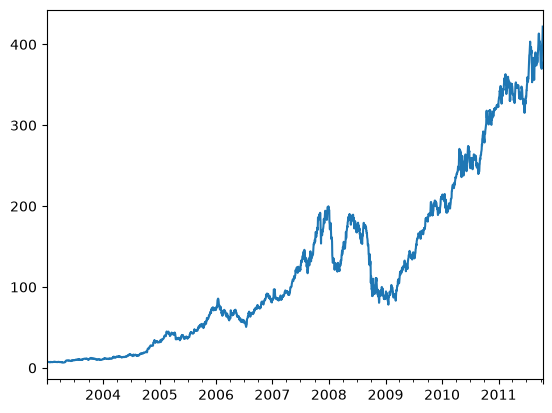

In [112]:
close_px['AAPL'].plot() # 单列

<Axes: >

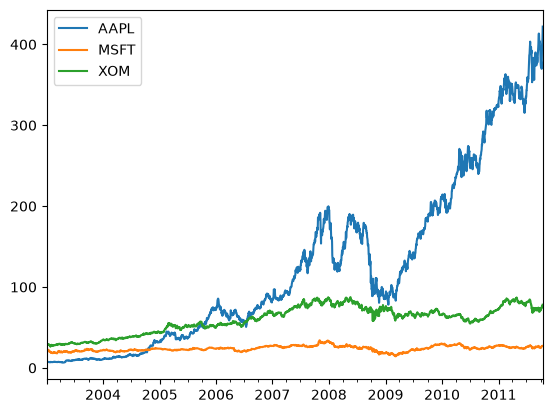

In [113]:
close_px.plot() # 所有列

<Axes: >

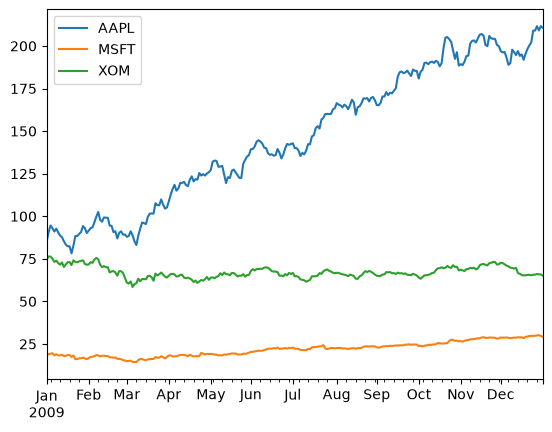

In [114]:
close_px.loc['2009'].plot()

<Axes: >

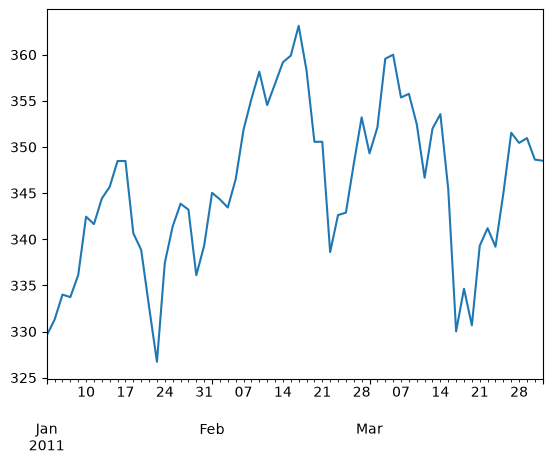

In [115]:
close_px['AAPL'].loc['2011-01':'2011-03'].plot() # 筛选时期

<Axes: >

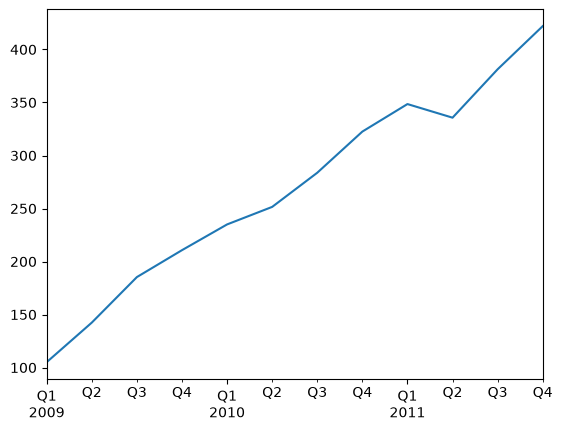

In [116]:
close_px['AAPL'].resample('QE-DEC').ffill().loc['2009':].plot()

### 移动窗口函数(moving window function)

<Axes: >

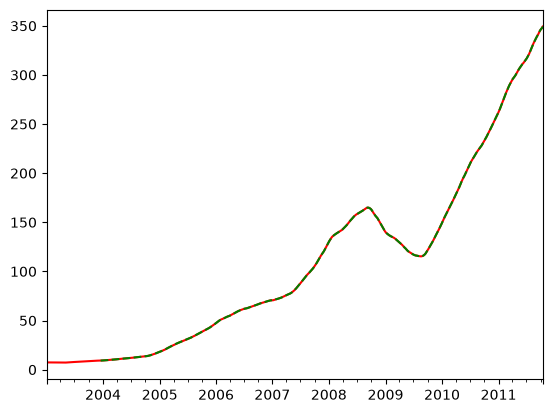

In [117]:
#close_px['AAPL'].plot()
# 移动平均值
#pd.rolling_mean(close_px['AAPL'], 250).plot() # deprecated
# window表示期, min_periods表示窗口中非NA的数据数量
close_px['AAPL'].rolling(center=False, window=250, min_periods=10).mean().plot(style=['r'])
close_px['AAPL'].rolling(center=False, window=250).mean().plot(style='g--') 

<Axes: >

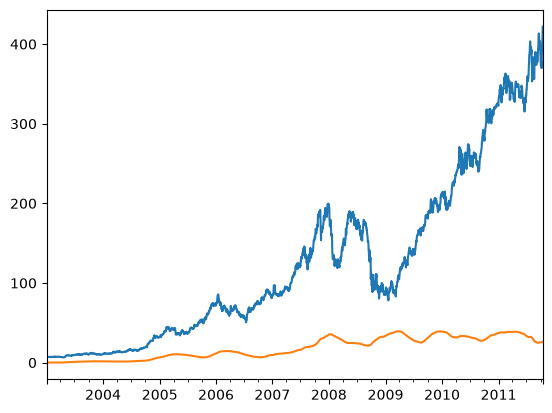

In [118]:
close_px['AAPL'].plot()
# 移动标准差
close_px['AAPL'].rolling(center=False, window=250, min_periods=10).std().plot()

<Axes: >

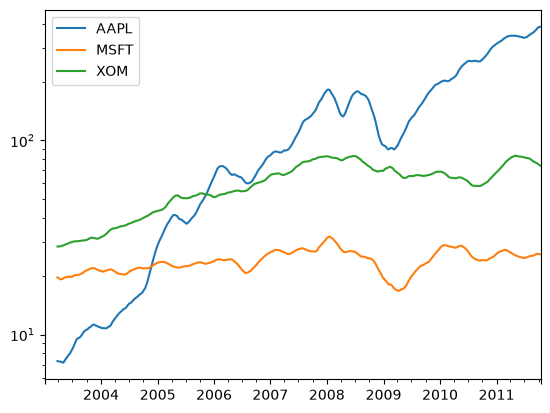

In [119]:
# 应用到所有列上
close_px.rolling(window=60).mean().plot(logy=True)

### 指数加权: 使近期的观测值有更大的权重

Text(0.5, 1.0, '指数加权移动平均')

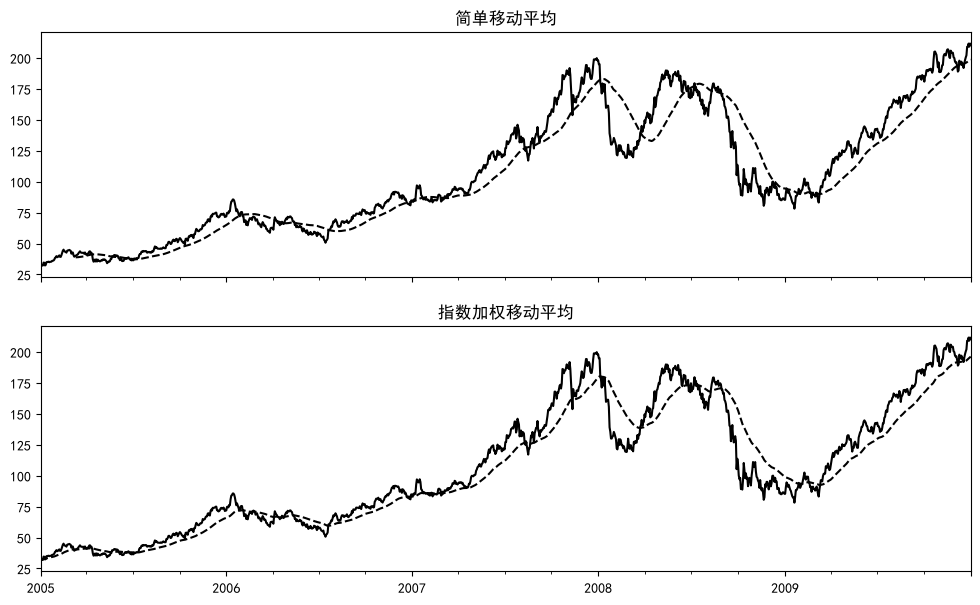

In [120]:
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei'] # 指定默认字体为黑体（SimHei）
plt.rcParams['axes.unicode_minus'] = False # 解决保存图像时负号 '-' 显示为方块的问题

fig, axes = plt.subplots(nrows=2,ncols=1,
                         sharex=True,sharey=True,
                        figsize=(12,7))
appl_px = close_px['AAPL']['2005':'2009']
ma = appl_px.rolling(window=60, min_periods=50).mean() # 简单移动平均
ewma = appl_px.ewm(span=60).mean() # 指数加权移动平均

appl_px.plot(style='k-', ax=axes[0])
ma.plot(style='k--', ax=axes[0])
axes[0].set_title(u'简单移动平均')

appl_px.plot(style='k-', ax=axes[1])
ewma.plot(style='k--', ax=axes[1])
axes[1].set_title(u'指数加权移动平均')

### 二元移动窗口函数: 计算相关系数和协方差等

<Axes: >

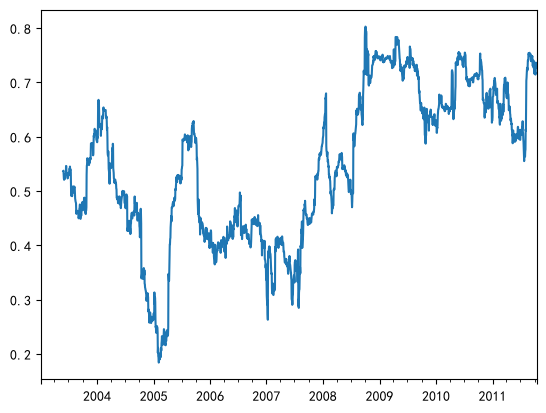

In [121]:
spx_px = close_px_all['SPX']
spx_rets = spx_px / spx_px.shift(1) - 1
returns = close_px.pct_change() # 百分数变化
returns['AAPL'].rolling(window=125, min_periods=100).corr(spx_rets).plot() # 协方差

### 用户自定义的移动窗口函数: 在窗口内数据序列上应用结果为标量的函数

<Axes: >

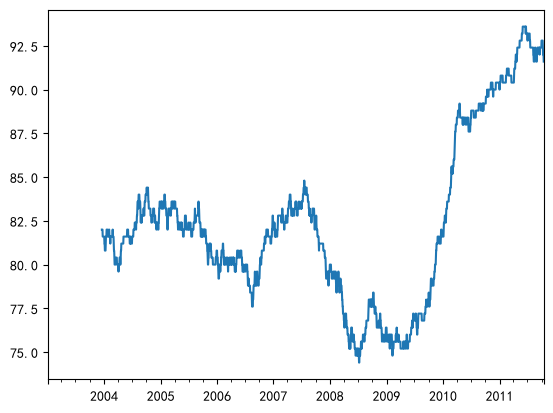

In [122]:
from scipy.stats import percentileofscore
score_at_2percent = lambda x : percentileofscore(x, 0.02) # 2%分位处的值
returns['AAPL'].rolling(window=250).apply(score_at_2percent).plot()

### 自定义

ts1: [ 1 1.2 ], ts2: [ 1.1 1.3 ]


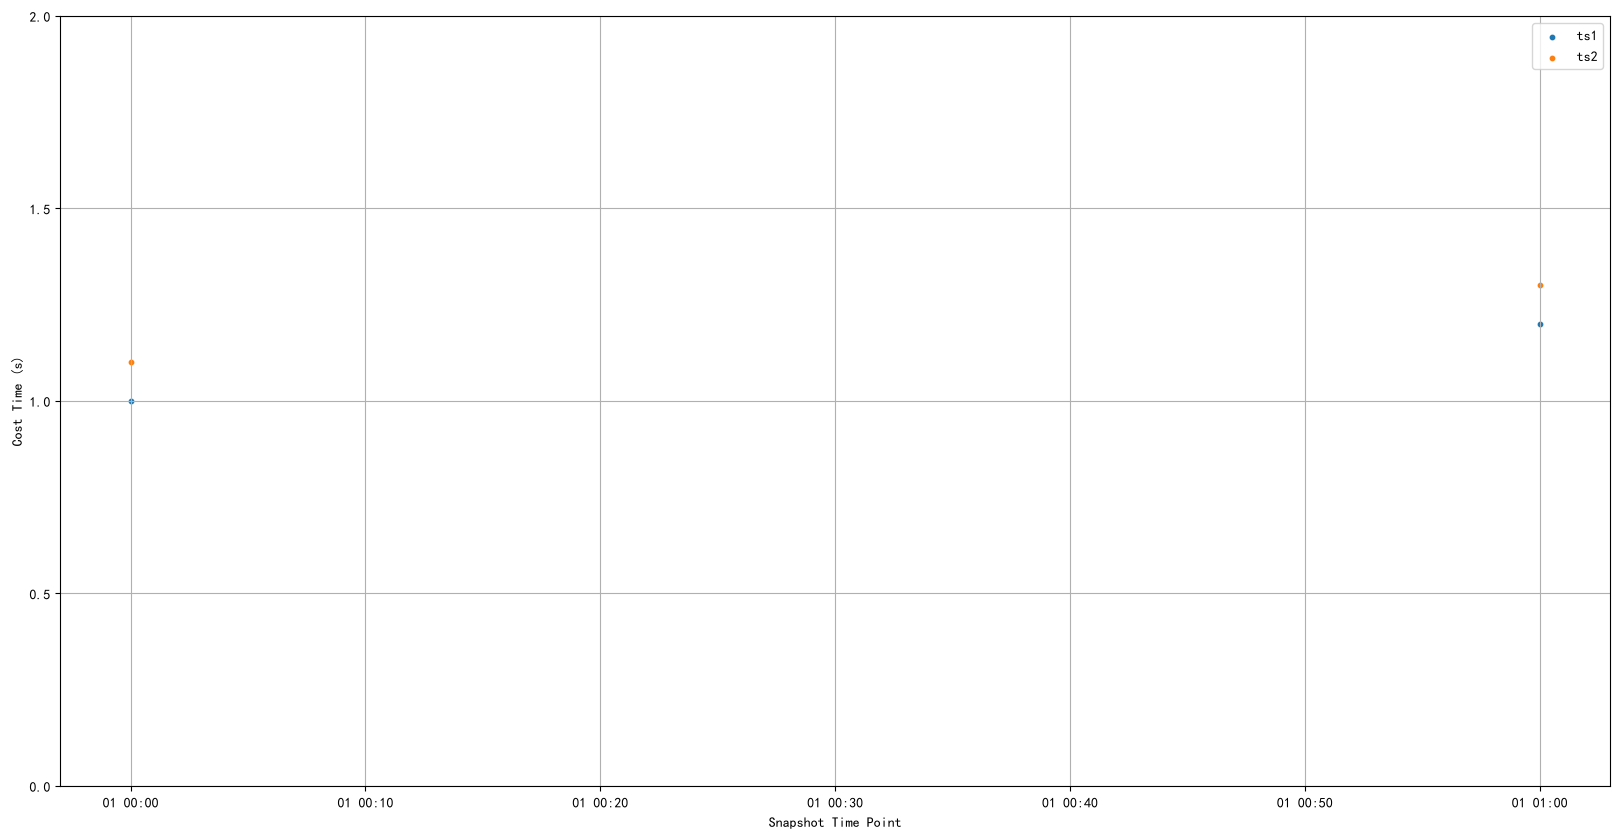

: 

In [ ]:
%matplotlib inline
from matplotlib import pyplot as plt

import numpy as np
import datetime

def plot_array_tuple(arr_tuple, style='green', label=None):
    x = [datetime.datetime.strptime(a, '%Y-%m-%d %H:%M:%S') for (a, _) in arr_tuple]
    y = [b for (_, b) in arr_tuple]
    if label is None:
        p, = plt.plot(x, y, style)
        return p
    else:
        plt.scatter(x, y, label=label, s=10)
        return None

def plot_time_series(ts1, ts2, label1, label2):
    """ts: [('2021-01-01 00:00:00', duration)]"""
    fig = plt.gcf()
    fig.set_size_inches(20, 10)

    plt.xlabel("Snapshot Time Point")
    plt.ylabel("Cost Time (s)")

# scatter
    p1 = plot_array_tuple(ts1, style='g',label=label1)
    p2 = plot_array_tuple(ts2, style='r',label=label2)

# line
#     p1 = plot_array_tuple(ts1, style='g')
#     p2 = plot_array_tuple(ts2, style='r')

    if p1 is not None:
        plt.legend([p1, p2], [label1, label2])
    else:
        _min1 = min([b for (_, b) in ts1])
        _min2 = min([b for (_, b) in ts2])
        _max1 = max([b for (_, b) in ts1])
        _max2 = max([b for (_, b) in ts2])
        print("ts1: [", _min1, _max1, "], ts2: [", _min2, _max2, "]")
        _max = max(_max1-_min1, _max2-_min1)
        if _max >= 10:
            _step = 5
        else:
            _step = 0.5
        plt.yticks(np.arange(min(_min1, _min2) - 1, max(_max1, _max2) + 1, _step))
        plt.legend()

    plt.grid(True)
    plt.show()

    #fig.savefig('ts.png', dpi=100)

ts1 = [('2021-01-01 00:00:00', 1), ('2021-01-01 01:00:00', 1.2)]
ts2 = [('2021-01-01 00:00:00', 1.1), ('2021-01-01 01:00:00', 1.3)]
plot_time_series(ts1,ts2, 'ts1', 'ts2')


# DataFrame

In [123]:
%matplotlib inline

In [124]:
columns = ['Name', 'Team', 'Score', 'EventTime', 'ProcTime']
data = [
    ['Julie', 'TeamX', 5, pd.to_datetime('12:00:26'), pd.to_datetime('12:05:19')],
    ['Frank', 'TeamX', 9, pd.to_datetime('12:01:26'), pd.to_datetime('12:08:19')],
    ['Ed', 'TeamX', 7, pd.to_datetime('12:02:26'), pd.to_datetime('12:05:39')],
    ['Julie', 'TeamX', 8, pd.to_datetime('12:03:06'), pd.to_datetime('12:07:06')],
    ['Amy', 'TeamX', 3, pd.to_datetime('12:03:39'), pd.to_datetime('12:06:13')],
    ['Fred', 'TeamX', 4, pd.to_datetime('12:04:19'), pd.to_datetime('12:06:39')],
    ['Naomi', 'TeamX', 3, pd.to_datetime('12:06:39'), pd.to_datetime('12:07:19')],
    ['Becky', 'TeamX', 8, pd.to_datetime('12:07:26'), pd.to_datetime('12:08:39')],
    ['Naomi', 'TeamX', 1, pd.to_datetime('12:07:46'), pd.to_datetime('12:09:00')],
]
df = pd.DataFrame(data=data, columns=columns)

In [125]:
df

,Name,Team,Score,EventTime,ProcTime
0,Julie,TeamX,5,2026-09-20 12:00:26,2026-09-20 12:05:19
1,Frank,TeamX,9,2026-09-20 12:01:26,2026-09-20 12:08:19
2,Ed,TeamX,7,2026-09-20 12:02:26,2026-09-20 12:05:39
3,Julie,TeamX,8,2026-09-20 12:03:06,2026-09-20 12:07:06
4,Amy,TeamX,3,2026-09-20 12:03:39,2026-09-20 12:06:13
5,Fred,TeamX,4,2026-09-20 12:04:19,2026-09-20 12:06:39
6,Naomi,TeamX,3,2026-09-20 12:06:39,2026-09-20 12:07:19
7,Becky,TeamX,8,2026-09-20 12:07:26,2026-09-20 12:08:39
8,Naomi,TeamX,1,2026-09-20 12:07:46,2026-09-20 12:09:00


<Axes: xlabel='EventTime'>

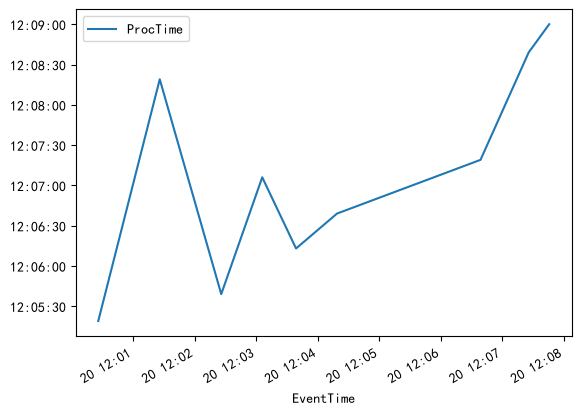

In [126]:
df.plot(x='EventTime', y='ProcTime', kind="line")

In [127]:
from datetime import datetime

a = pd.to_datetime('12:07:46')
a, a.timestamp()

#datetime.fromtimestamp(a.timestamp())
pd.Timestamp(a)

Timestamp('2026-09-20 12:07:46')

In [128]:
data2 = [
    ['Julie', 'TeamX', 5, '12:00:26', '12:05:19'],
    ['Frank', 'TeamX', 9, '12:01:26', '12:08:19'],
    ['Ed', 'TeamX', 7, '12:02:26', '12:05:39'],
    ['Julie', 'TeamX', 8, '12:03:06', '12:07:06'],
    ['Amy', 'TeamX', 3, '12:03:39', '12:06:13'],
    ['Fred', 'TeamX', 4, '12:04:19', '12:06:39'],
    ['Naomi', 'TeamX', 3, '12:06:39', '12:07:19'],
    ['Becky', 'TeamX', 8, '12:07:26', '12:08:39'],
    ['Naomi', 'TeamX', 1, '12:07:46', '12:09:00'],
]
df2 = pd.DataFrame(data=data2, columns=columns)

In [129]:
df2

,Name,Team,Score,EventTime,ProcTime
0,Julie,TeamX,5,12:00:26,12:05:19
1,Frank,TeamX,9,12:01:26,12:08:19
2,Ed,TeamX,7,12:02:26,12:05:39
3,Julie,TeamX,8,12:03:06,12:07:06
4,Amy,TeamX,3,12:03:39,12:06:13
5,Fred,TeamX,4,12:04:19,12:06:39
6,Naomi,TeamX,3,12:06:39,12:07:19
7,Becky,TeamX,8,12:07:26,12:08:39
8,Naomi,TeamX,1,12:07:46,12:09:00


In [130]:
df2['EventTime'].apply(lambda x: pd.to_datetime(x))
df2['ProcTime'].apply(lambda x: pd.to_datetime(x))

0   2026-09-20 12:05:19
1   2026-09-20 12:08:19
2   2026-09-20 12:05:39
3   2026-09-20 12:07:06
4   2026-09-20 12:06:13
5   2026-09-20 12:06:39
6   2026-09-20 12:07:19
7   2026-09-20 12:08:39
8   2026-09-20 12:09:00
Name: ProcTime, dtype: datetime64[us]

In [131]:
df2['EventTime'] = df2['EventTime'].apply(lambda x: pd.to_datetime(x))
df2['ProcTime'] = df2['ProcTime'].apply(lambda x: pd.to_datetime(x))
df2

,Name,Team,Score,EventTime,ProcTime
0,Julie,TeamX,5,2026-09-20 12:00:26,2026-09-20 12:05:19
1,Frank,TeamX,9,2026-09-20 12:01:26,2026-09-20 12:08:19
2,Ed,TeamX,7,2026-09-20 12:02:26,2026-09-20 12:05:39
3,Julie,TeamX,8,2026-09-20 12:03:06,2026-09-20 12:07:06
4,Amy,TeamX,3,2026-09-20 12:03:39,2026-09-20 12:06:13
5,Fred,TeamX,4,2026-09-20 12:04:19,2026-09-20 12:06:39
6,Naomi,TeamX,3,2026-09-20 12:06:39,2026-09-20 12:07:19
7,Becky,TeamX,8,2026-09-20 12:07:26,2026-09-20 12:08:39
8,Naomi,TeamX,1,2026-09-20 12:07:46,2026-09-20 12:09:00


<Axes: xlabel='EventTime'>

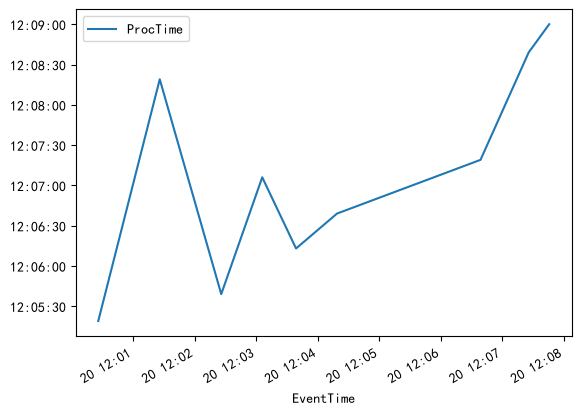

In [132]:
df2.plot(x='EventTime', y='ProcTime', kind="line", 
         #xticks=df2['EventTime'].apply(lambda x: pd.to_datetime(x)),
         #yticks=df2['ProcTime'].apply(lambda x: pd.to_datetime(x))
        )

# Cleanup